In [16]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse.linalg import svds

In [17]:
class Config:
    done_text = 'v1 (150)/1 Billion Citation Dataset, v1 (150)(done_text).csv'
    count_df_path = 'v1 (150)/1 Billion Citation Dataset, v1 (150)(count matrix).csv'
    SVD_count_df_path = 'v1 (150)/1 Billion Citation Dataset, v1 (150)(SVD matrix).csv'
    Tfidf_path = 'v1 (150)/1 Billion Citation Dataset, v1 (150)(Tfidf).csv'

    text_col = 'Title'

# Import data

In [18]:
df = pd.read_csv(Config.done_text, nrows=100000)[[Config.text_col]]
print(df.shape)
df.head()

(100000, 1)


,Title
0,front matter
1,endtoend schedul approach mealtim cobra
2,asymptot law onedimens diffu condit nonabsorpt
3,cancer case attribut alcohol consumpt brazil
4,evid overweight longer survivor childhood canc...


In [19]:
# Drop NAN
df.dropna(inplace=True)

In [20]:
# Tạo một cột nhóm để chia thành từng khối 100 dòng
df['group'] = df.index // 100

# Gộp các chuỗi trong từng nhóm thành một chuỗi duy nhất
result = df.groupby('group')[Config.text_col].apply(' '.join).reset_index(drop=True)

# Kết quả là một Series, có thể chuyển thành DataFrame nếu cần
result_df = result.to_frame(name='Title')

print(df.shape)
result_df.head()

(100000, 2)


,Title
0,front matter endtoend schedul approach mealtim...
1,studi drill characterist implant procedur dril...
2,erratum pharmacoepidemiolog drug safety—harmon...
3,small bowel transplant diffu intestin angiomat...
4,numer investig spatial period deform select ne...


# Term-document matrix

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
# Apply CountVectorizer
Cvectorizer = CountVectorizer()
X = Cvectorizer.fit_transform(result_df[Config.text_col])

# Chuyển thành DataFrame với các cột là từ trong từ vựng
count_matrix = X.toarray().astype(float)
all_the_words = Cvectorizer.get_feature_names_out()
count_matrix_df = pd.DataFrame(count_matrix, columns=all_the_words)
print(count_matrix_df.shape)
count_matrix_df.head()

(1000, 7740)


,00,000,003,016,018x03bcm,0262611368,080974,086r87r,10,1000,...,терентьева,территории,технологии,химической,циклогексана,цифровую,эпоху,японии,ἐγκακοπαϑέω,生物质炭添加对毛竹林土壤呼吸动态和温度敏感性的影响
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0


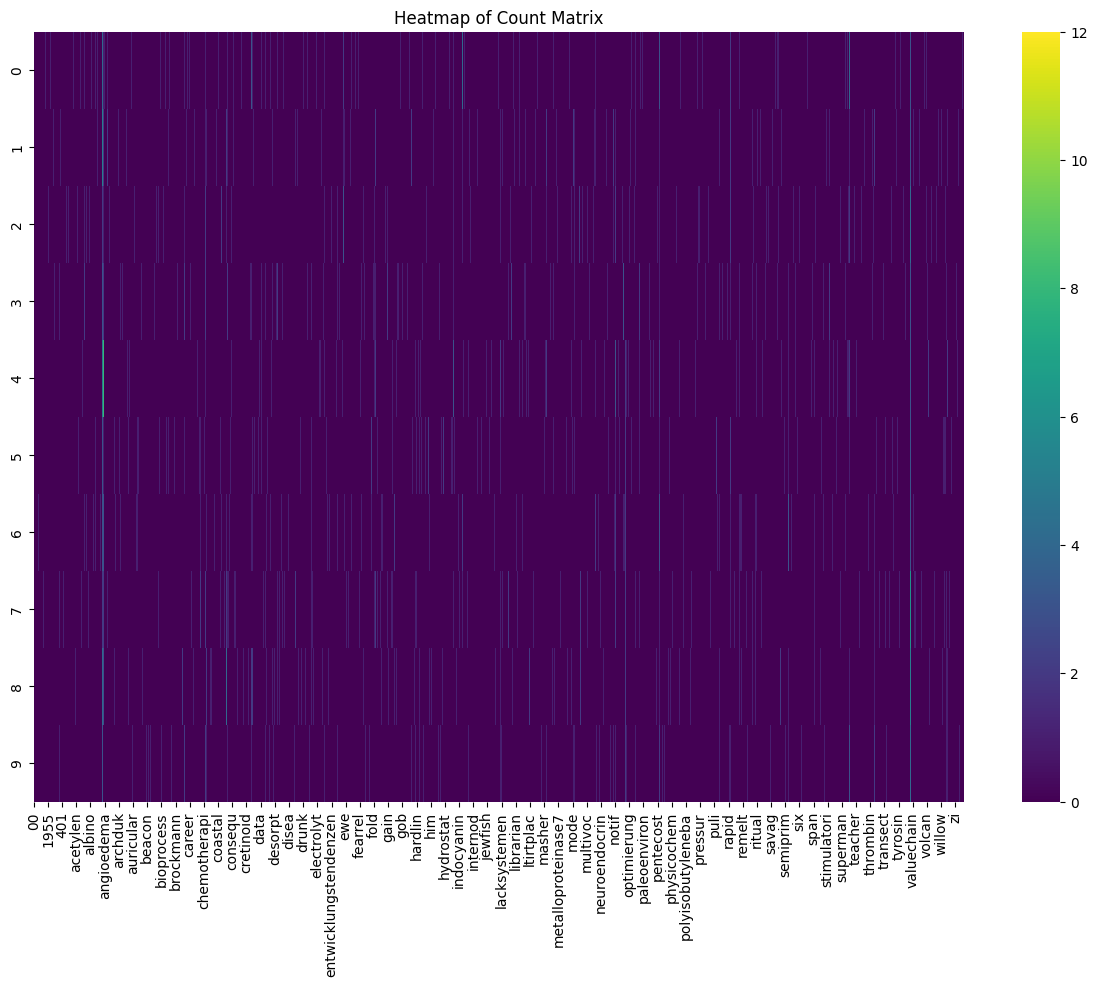

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))  # Set the figure size
sns.heatmap(count_matrix_df.iloc[:10], cmap='viridis')  # Create the heatmap
plt.title('Heatmap of Count Matrix')  # Add a title
plt.show()  # Display the heatmap

# Tfidf matrix

In [22]:
Tvectorizer = TfidfVectorizer()
X1 = Tvectorizer.fit_transform(result_df[Config.text_col]).toarray()[0]

# Tạo danh sách lưu thông tin của các từ có tf-idf khác 0
data = []
for i in range(len(X1)):
    if X1[i] != 0:
        data.append({
            'index': i,
            'idf': round(Tvectorizer.idf_[i], 4),
            'tfidf': round(X1[i], 4),
            'term': Tvectorizer.get_feature_names_out()[i]
        })

# Chuyển danh sách thành DataFrame
frequency_matrix = pd.DataFrame(data)

print(frequency_matrix.shape)
frequency_matrix.head()

(620, 4)


,index,idf,tfidf,term
0,9,2.6723,0.0303,1000
1,61,4.3252,0.0491,172008
2,97,3.6461,0.0414,1910
3,98,4.3252,0.0491,1911
4,139,4.3252,0.0491,1989


# Perform SVD

In [23]:
# Keep 70% of the data
percent_value_data = 100 #(np.min([count_matrix.shape[0], count_matrix.shape[1]]) * 0.7) // 1 
print(percent_value_data)

# SVD
U, sigma, Vt = svds(count_matrix, k=percent_value_data)
print(f"U shape:     {U.shape}")
print(f"sigma shape: {sigma.shape}")
print(f"Vt shape:    {Vt.shape}")

# After SVD matrix
X3 = U.dot(np.diag(sigma)).dot(Vt)
SVD_count_matrix = pd.DataFrame(X3, columns=all_the_words)
print(SVD_count_matrix.shape)
SVD_count_matrix.head()


100
U shape:     (1000, 100)
sigma shape: (100,)
Vt shape:    (100, 7740)
(1000, 7740)


,00,000,003,016,018x03bcm,0262611368,080974,086r87r,10,1000,...,терентьева,территории,технологии,химической,циклогексана,цифровую,эпоху,японии,ἐγκακοπαϑέω,生物质炭添加对毛竹林土壤呼吸动态和温度敏感性的影响
0,-0.010333,0.024576,-0.004422,0.009198,-0.021259,-0.000338,0.010305,0.013402,-0.048804,1.135732,...,0.020532,0.014378,1.015268,1.015268,1.015268,0.020532,0.020532,0.020532,0.076516,-0.010625
1,0.006380,-0.025071,0.019478,-0.017940,-0.018055,0.012543,-0.004583,0.001644,0.052656,1.720622,...,-0.009962,-0.030768,-0.007802,-0.007802,-0.007802,-0.009962,-0.009962,-0.009962,0.028202,-0.004067
2,-0.002645,0.000741,-0.018489,0.023657,-0.003509,0.000257,-0.008593,-0.013273,-0.044118,-0.135515,...,-0.001857,-0.006066,-0.027990,-0.027990,-0.027990,-0.001857,-0.001857,-0.001857,-0.027471,-0.006742
3,-0.011796,-0.019378,0.007352,0.024016,0.009901,-0.006038,-0.002490,-0.022125,-0.047155,0.085633,...,0.005574,-0.008298,0.052830,0.052830,0.052830,0.005574,0.005574,0.005574,-0.009103,-0.026491
4,-0.010975,0.014548,0.010324,-0.032629,1.010409,-0.010073,0.012609,-0.000206,0.064297,-0.022859,...,1.002848,0.008260,-0.000592,-0.000592,-0.000592,1.002848,1.002848,1.002848,-0.003124,-0.013219


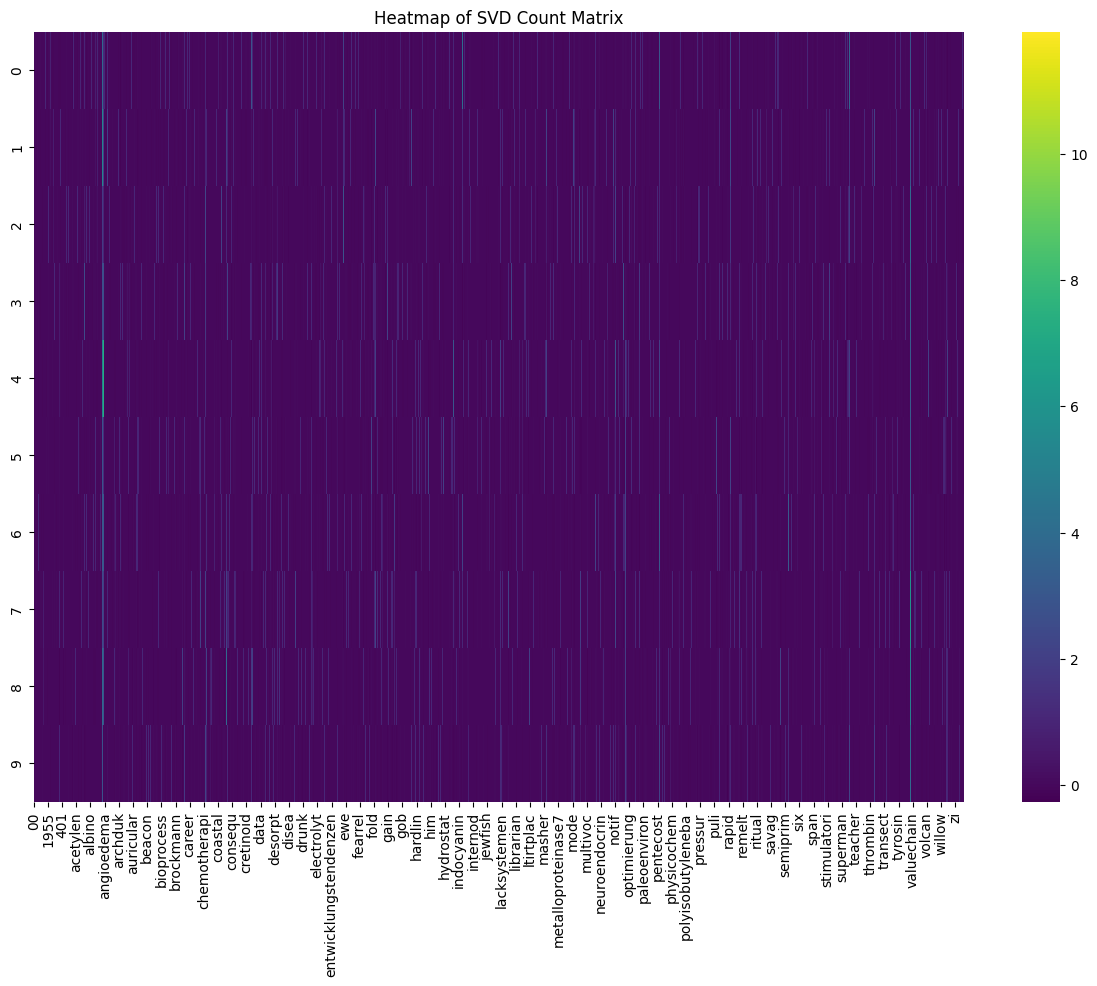

In [26]:
plt.figure(figsize=(15, 10))  # Set the figure size
sns.heatmap(SVD_count_matrix.iloc[:10], cmap='viridis')  # Create the heatmap
plt.title('Heatmap of SVD Count Matrix')  # Add a title
plt.show()  # Display the heatmap

# Export data

In [25]:
count_matrix_df.to_csv(Config.count_df_path, index=False)
frequency_matrix.to_csv(Config.Tfidf_path, index=False)
SVD_count_matrix.to_csv(Config.SVD_count_df_path, index=False)